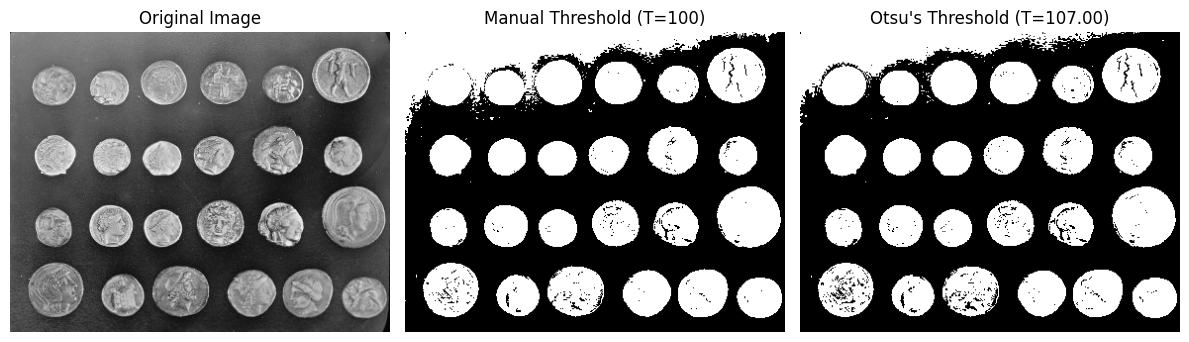

Nilai threshold Otsu yang ditemukan: 107


In [1]:
import matplotlib.pyplot as plt
from skimage import data, filters

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()  # Citra sudah grayscale

# 2. Thresholding Global (manual)
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Visualisasi hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

# Gambar asli
ax[0].imshow(image_coins, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

# Threshold manual
ax[1].imshow(binary_manual, cmap='gray')
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

# Threshold Otsu
ax[2].imshow(binary_otsu, cmap='gray')
ax[2].set_title(f"Otsu's Threshold (T={thresh_otsu:.2f})")
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Menampilkan nilai threshold Otsu
print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

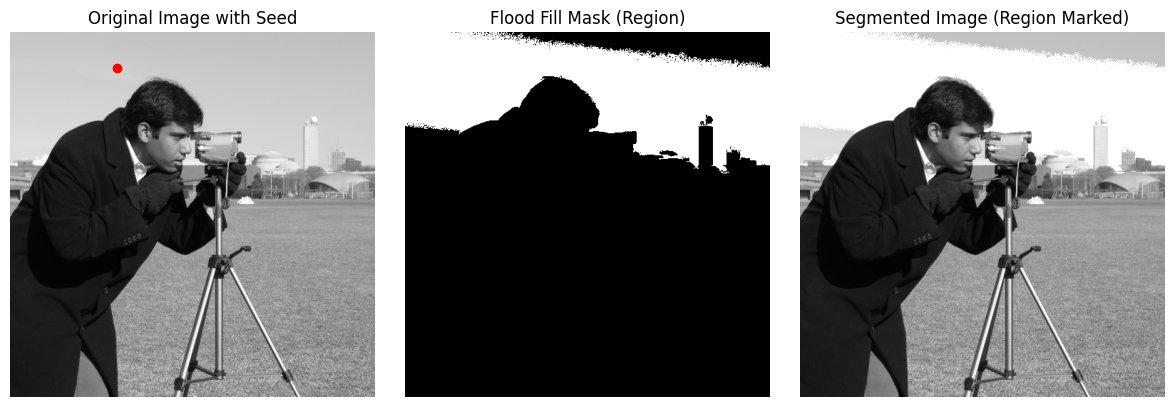

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation

# 1. Memuat citra (contoh: camera)
image_camera = data.camera()

# 2. Tentukan titik seed (benih)
# Contoh: titik di area langit
seed_point = (50, 150)  # (y, x)

# 3. Terapkan algoritma flood fill (mirip region growing)
# tolerance = batas perbedaan intensitas
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. Buat citra hasil segmentasi
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255  # tandai region dengan warna putih

# 5. Visualisasi hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

# Gambar asli + seed point
ax[0].imshow(image_camera, cmap='gray')
ax[0].plot(seed_point[1], seed_point[0], 'ro')
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

# Mask hasil flood fill
ax[1].imshow(flood_mask, cmap='gray')
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

# Hasil segmentasi
ax[2].imshow(segmented_image, cmap='gray')
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

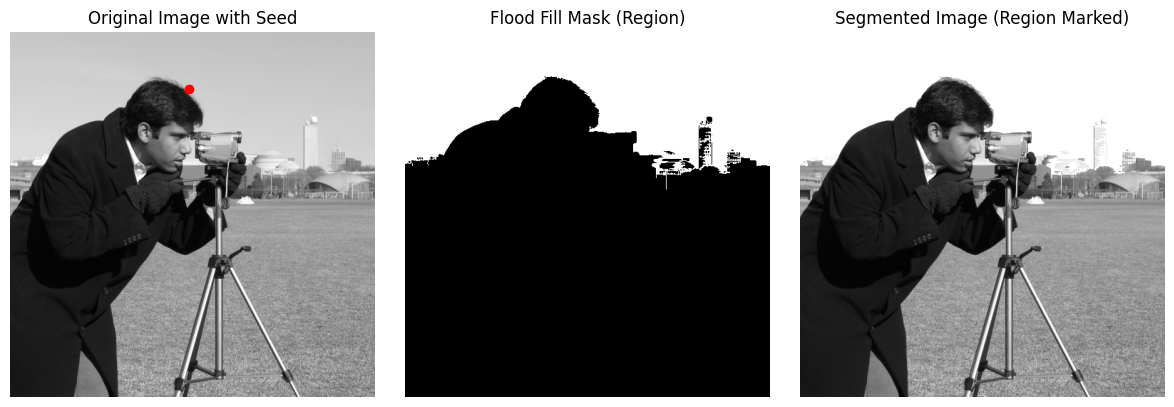

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation

# 1. Memuat citra (contoh: camera)
image_camera = data.camera()

# 2. Tentukan titik seed (benih)
# Contoh: titik di area langit
seed_point = (80, 250)  # (y, x)

# 3. Terapkan algoritma flood fill (mirip region growing)
# tolerance = batas perbedaan intensitas
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=20)

# 4. Buat citra hasil segmentasi
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255  # tandai region dengan warna putih

# 5. Visualisasi hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

# Gambar asli + seed point
ax[0].imshow(image_camera, cmap='gray')
ax[0].plot(seed_point[1], seed_point[0], 'ro')
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

# Mask hasil flood fill
ax[1].imshow(flood_mask, cmap='gray')
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

# Hasil segmentasi
ax[2].imshow(segmented_image, cmap='gray')
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

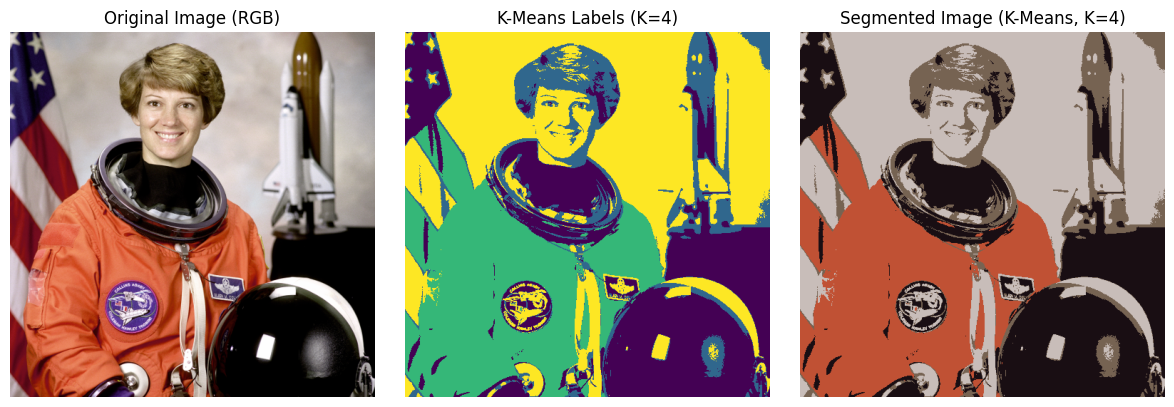

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
import sklearn.cluster
from skimage.color import rgb2lab, lab2rgb
import warnings

# =========================
# 1. Memuat citra berwarna
# =========================
image_astro = data.astronaut()

# Konversi ke float (0–1)
image_astro_float = image_astro.astype(float) / 255.0

# =========================
# 2. Ubah ke ruang warna Lab
# =========================
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape

# Reshape jadi array piksel
pixel_features = image_lab.reshape(rows * cols, dims)

# =========================
# 3. K-Means Clustering
# =========================
n_clusters = 4

kmeans = sklearn.cluster.KMeans(
    n_clusters=n_clusters,
    random_state=0,
    n_init=10
)

# Hilangkan warning sklearn
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# =========================
# 4. Bentuk kembali label
# =========================
segmented_labels = pixel_labels.reshape(rows, cols)

# =========================
# 5. Buat citra segmentasi
# =========================
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_

for k in range(n_clusters):
    mask_k = (pixel_labels == k).reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]

# Konversi kembali ke RGB
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# =========================
# 6. Visualisasi
# =========================
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

# Gambar asli
ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

# Label klaster
ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

# Hasil segmentasi
ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

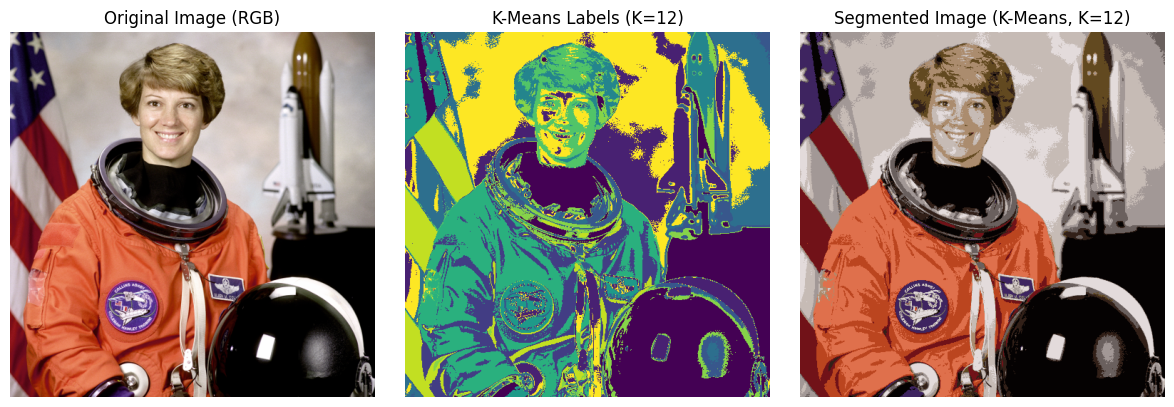

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
import sklearn.cluster
from skimage.color import rgb2lab, lab2rgb
import warnings

# =========================
# 1. Memuat citra berwarna
# =========================
image_astro = data.astronaut()

# Konversi ke float (0–1)
image_astro_float = image_astro.astype(float) / 255.0

# =========================
# 2. Ubah ke ruang warna Lab
# =========================
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape

# Reshape jadi array piksel
pixel_features = image_lab.reshape(rows * cols, dims)

# =========================
# 3. K-Means Clustering
# =========================
n_clusters = 12

kmeans = sklearn.cluster.KMeans(
    n_clusters=n_clusters,
    random_state=0,
    n_init=10
)

# Hilangkan warning sklearn
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# =========================
# 4. Bentuk kembali label
# =========================
segmented_labels = pixel_labels.reshape(rows, cols)

# =========================
# 5. Buat citra segmentasi
# =========================
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_

for k in range(n_clusters):
    mask_k = (pixel_labels == k).reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]

# Konversi kembali ke RGB
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# =========================
# 6. Visualisasi
# =========================
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

# Gambar asli
ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

# Label klaster
ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

# Hasil segmentasi
ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

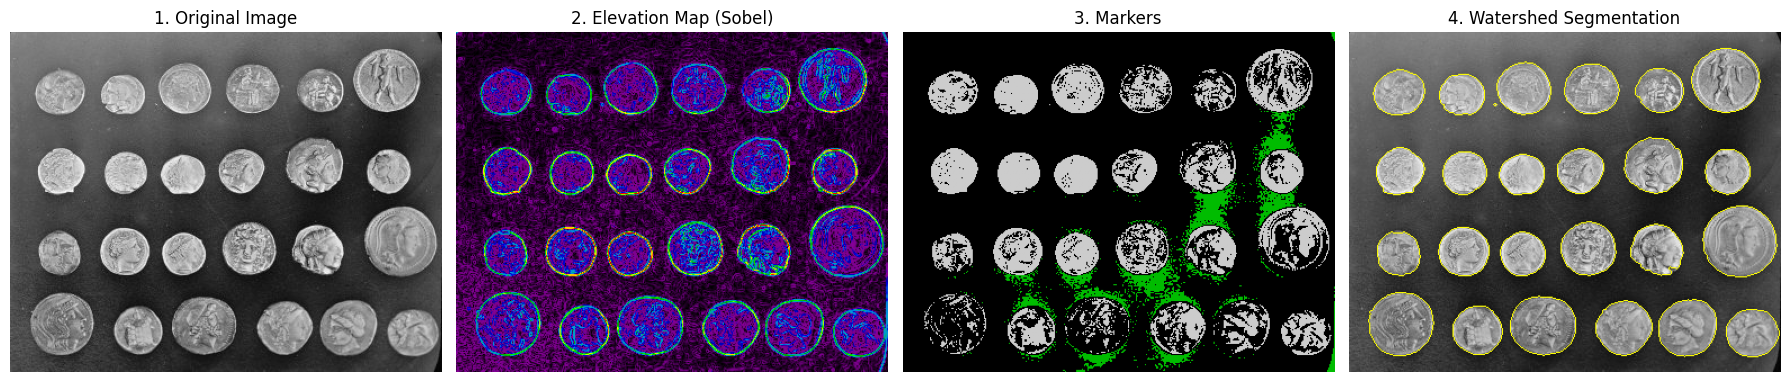

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, measure
from scipy import ndimage as ndi

# ==========================================
# 1. Memuat citra (contoh: coins)
# ==========================================
image_coins = data.coins()

# ==========================================
# 2. Hitung gradien citra (sebagai 'topografi')
# ==========================================
# Sobel filter digunakan untuk mencari tepi yang akan menjadi "bendungan"
elevation_map = filters.sobel(image_coins)

# ==========================================
# 3. Tentukan marker (penanda awal)
# ==========================================
# Membuat marker sederhana berdasarkan thresholding intensitas piksel
markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1   # Marker 1 untuk latar belakang (hitam)
markers[image_coins > 150] = 2  # Marker 2 untuk objek (koin)

# ==========================================
# 4. Terapkan algoritma Watershed
# ==========================================
# Algoritma "menggenangi" citra dari marker berdasarkan peta elevasi
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# Menghilangkan lubang kecil dan memberi label setiap objek secara unik
segmentation_watershed = ndi.binary_fill_holes(segmentation_watershed - 1)
labeled_coins, _ = ndi.label(segmentation_watershed)

# Warnai hasil segmentasi untuk visualisasi menggunakan mark_boundaries
segmented_colored = segmentation.mark_boundaries(image_coins, labeled_coins)

# ==========================================
# 5. Visualisasi Hasil
# ==========================================
fig, axes = plt.subplots(ncols=4, figsize=(18, 5), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('1. Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('2. Elevation Map (Sobel)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('3. Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('4. Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()

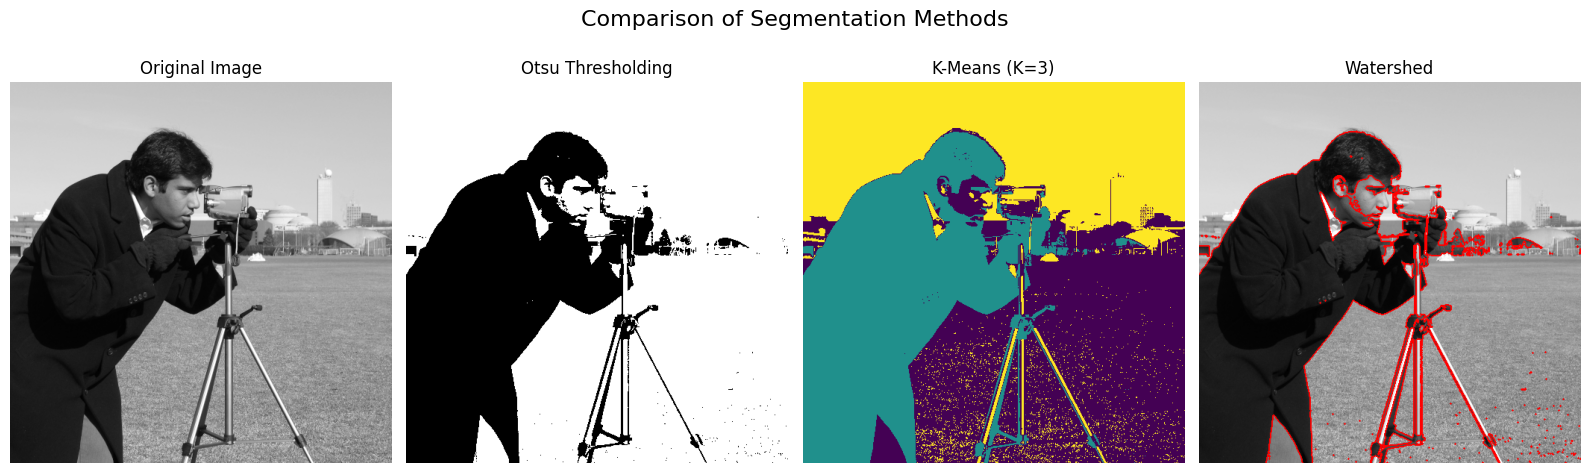

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float
from sklearn.cluster import KMeans
import numpy as np
import warnings

# ======================================
# 1. Pilih satu citra untuk perbandingan (misal: camera)
# ======================================
image = data.camera()
image_float = img_as_float(image)

# ======================================
# 2. Lakukan beberapa metode segmentasi
# ======================================

# a) Otsu Thresholding (Binerisasi)
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# b) K-Means (Klasterisasi intensitas piksel)
rows, cols = image.shape
# Reshape untuk K-Means (1 fitur: intensitas)
pixel_features = image_float.reshape(rows * cols, 1)
n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# c) Watershed (Segmentasi berbasis topografi dan marker)
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# ===================================
# 3. Visualisasi Perbandingan
# ===================================
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharex=True, sharey=True)
ax = axes.ravel()

# Citra Asli
ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

# Hasil Otsu
ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

# Hasil K-Means
ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

# Hasil Watershed dengan Batas (Mark Boundaries)
segmented_watershed_colored = segmentation.mark_boundaries(
    image_float, 
    segmentation_watershed, 
    color=(1, 0, 0)
)
ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()